# Monotonicity Analysis in Systems Optimization
### MECH 559 - Systems Optimization - L03

This notebook uses monotonicity to predict which constraints bound a design variable and which constraints may become active before solving the optimization problem.

## Learning objectives

By the end, you should be able to:

1. Determine monotonicity from partial derivatives and log sensitivities.
2. Apply a monotonicity table to the 2D cantilever beam design problem.
3. Predict bounding and active constraints, then check the prediction numerically.
4. Recognize when a function is not monotonic over the full design domain.
5. Partition a domain into monotonic regions using stationary points.

> **Classroom rhythm:** I will pause at each **Predict** prompt before revealing the plot or activity residuals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import minimize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"objective": "#00798C", "stress": "#D1495B", "deflection": "#2A9D8F", "optimum": "#EDAE49"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")

Optional widgets available: True


---
## 1. Define the 2D Beam Optimization Model

For a rectangular cantilever beam with height $h$ and width $b$,

$$W=\rho b h L,\qquad \sigma_{\max}=\frac{6PL}{bh^2},\qquad \delta_{\mathrm{tip}}=\frac{4PL^3}{Ebh^3}.$$

We solve

$$\min_{h,b} W(h,b)$$

subject to $\sigma_{\max}\leq\sigma_y$, $\delta_{\mathrm{tip}}\leq\delta_{\max}$, $10\leq h\leq150$ mm, and $10\leq b\leq100$ mm.

These constants and bounds match the L01 cantilever-beam notebook.

> **Predict:** If either $h$ or $b$ increases, what happens to each of the three functions?

In [2]:
P, L, rho, E = 1000.0, 1.0, 7850.0, 200e9
sigma_y, delta_max = 250e6, 5e-3
h_min, h_max = 0.01, 0.15
b_min, b_max = 0.01, 0.10


def mass(h, b, density=rho, length=L):
    return density * b * h * length


def sigma_max(h, b, load=P, length=L):
    return 6 * load * length / (b * h**2)


def delta_tip(h, b, load=P, length=L, modulus=E):
    return 4 * load * length**3 / (modulus * b * h**3)


h_test, b_test = 0.05, 0.05
assert np.isclose(mass(h_test, b_test), 19.625)
assert sigma_max(1.01 * h_test, b_test) < sigma_max(h_test, b_test)
assert delta_tip(h_test, 1.01 * b_test) < delta_tip(h_test, b_test)
print(f"At h=b=50 mm: W={mass(h_test, b_test):.3f} kg, "
      f"sigma={sigma_max(h_test, b_test)/1e6:.2f} MPa, "
      f"delta={delta_tip(h_test, b_test)*1e3:.3f} mm")

At h=b=50 mm: W=19.625 kg, sigma=48.00 MPa, delta=3.200 mm


---
## 2. Determine Monotonicity Symbolically

For a positive function $f$, the log sensitivity

$$S_x^f=\frac{x}{f}\frac{\partial f}{\partial x}$$

is especially useful: its sign gives the direction and its magnitude gives the power-law exponent.

> **Predict:** Complete the signs in the table before running the symbolic cell.

| Function | with respect to $h$ | with respect to $b$ |
|---|---:|---:|
| $W$ | ? | ? |
| $\sigma_{\max}$ | ? | ? |
| $\delta_{\mathrm{tip}}$ | ? | ? |

In [3]:
h_sym, b_sym = sp.symbols("h b", positive=True)
P_sym, L_sym, rho_sym, E_sym = sp.symbols("P L rho E", positive=True)
expressions = {
    "W": rho_sym * b_sym * h_sym * L_sym,
    "sigma": 6 * P_sym * L_sym / (b_sym * h_sym**2),
    "delta": 4 * P_sym * L_sym**3 / (E_sym * b_sym * h_sym**3),
}

print(f"{'function':<10} {'d/dh sign':>12} {'d/db sign':>12} {'S_h':>8} {'S_b':>8}")
for name, expression in expressions.items():
    derivative_h = sp.factor(sp.diff(expression, h_sym))
    derivative_b = sp.factor(sp.diff(expression, b_sym))
    sensitivity_h = sp.simplify(h_sym * derivative_h / expression)
    sensitivity_b = sp.simplify(b_sym * derivative_b / expression)
    sign_h = "+" if sensitivity_h > 0 else "-"
    sign_b = "+" if sensitivity_b > 0 else "-"
    print(f"{name:<10} {sign_h:>12} {sign_b:>12} {str(sensitivity_h):>8} {str(sensitivity_b):>8}")

assert sp.simplify(h_sym * sp.diff(expressions["delta"], h_sym) / expressions["delta"]) == -3
assert sp.simplify(b_sym * sp.diff(expressions["W"], b_sym) / expressions["W"]) == 1

function      d/dh sign    d/db sign      S_h      S_b
W                     +            +        1        1
sigma                 -            -       -2       -1
delta                 -            -       -3       -1


---
## 3. Visualize the Beam Design Space

Because mass increases in both variables while stress and deflection decrease, reducing material pushes the design toward the constraint boundaries. Monotonicity predicts a boundary optimum, but it does not alone decide which of stress, deflection, or a side bound is active.

The plot overlays mass contours, the feasible region, and the numerical optimum.

> **Predict:** Which constraint boundary will contain the optimum? Will the lower width bound be active?

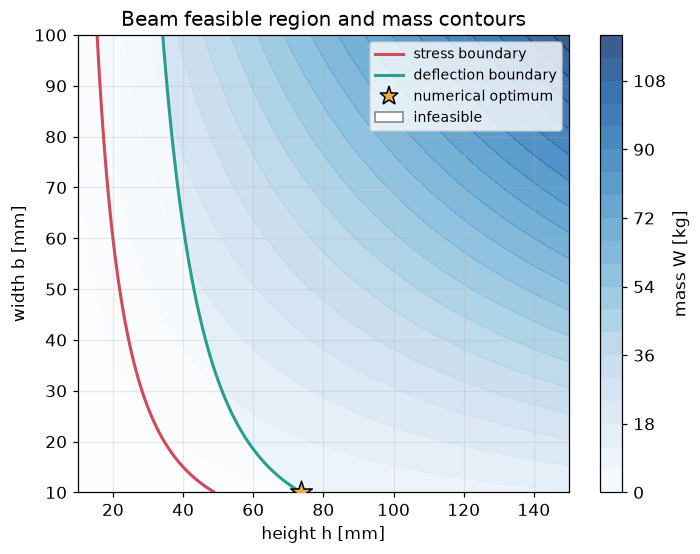

h*=73.681 mm; b*=10.000 mm; W*=5.7839 kg


In [4]:
def solve_beam(load=P, length=L, density=rho, modulus=E,
               allowable_stress=sigma_y, allowable_deflection=delta_max):
    to_metres = 1e-3
    objective = lambda design_mm: mass(design_mm[0] * to_metres, design_mm[1] * to_metres, density, length)
    constraints = [
        {"type": "ineq", "fun": lambda design_mm: 1 - sigma_max(design_mm[0] * to_metres, design_mm[1] * to_metres, load, length) / allowable_stress},
        {"type": "ineq", "fun": lambda design_mm: 1 - delta_tip(design_mm[0] * to_metres, design_mm[1] * to_metres, load, length, modulus) / allowable_deflection},
    ]
    result = minimize(objective, [80.0, 30.0], method="SLSQP",
                      bounds=[(h_min * 1e3, h_max * 1e3), (b_min * 1e3, b_max * 1e3)],
                      constraints=constraints, options={"ftol": 1e-12, "maxiter": 1000})
    result.x = result.x * to_metres
    return result


def plot_beam_space(load=P, length=L, density=rho, modulus=E,
                    allowable_stress=sigma_y, allowable_deflection=delta_max):
    h_values = np.linspace(h_min, h_max, 320)
    b_values = np.linspace(b_min, b_max, 280)
    H, B = np.meshgrid(h_values, b_values)
    W = mass(H, B, density, length)
    Sigma = sigma_max(H, B, load, length)
    Delta = delta_tip(H, B, load, length, modulus)
    feasible = (Sigma <= allowable_stress) & (Delta <= allowable_deflection)
    result = solve_beam(load, length, density, modulus, allowable_stress, allowable_deflection)

    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    contours = ax.contourf(H * 1e3, B * 1e3, W, levels=22, cmap="Blues", alpha=0.8)
    ax.contourf(H * 1e3, B * 1e3, feasible.astype(float), levels=[-0.5, 0.5], colors="white", alpha=0.7)
    ax.contour(H * 1e3, B * 1e3, Sigma / 1e6, levels=[allowable_stress / 1e6], colors=COLORS["stress"], linewidths=2)
    ax.contour(H * 1e3, B * 1e3, Delta * 1e3, levels=[allowable_deflection * 1e3], colors=COLORS["deflection"], linewidths=2)
    if result.success:
        ax.scatter(result.x[0] * 1e3, result.x[1] * 1e3, marker="*", s=220,
                   color=COLORS["optimum"], edgecolor="black", zorder=5)
    ax.set(xlabel="height h [mm]", ylabel="width b [mm]", title="Beam feasible region and mass contours")
    plt.colorbar(contours, ax=ax, label="mass W [kg]")
    ax.legend(handles=[
        Line2D([0], [0], color=COLORS["stress"], lw=2, label="stress boundary"),
        Line2D([0], [0], color=COLORS["deflection"], lw=2, label="deflection boundary"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor=COLORS["optimum"],
               markeredgecolor="black", markersize=13, label="numerical optimum"),
        Patch(facecolor="white", edgecolor="gray", label="infeasible"),
    ], fontsize=9)
    plt.show()
    return result


beam_result = plot_beam_space()
assert beam_result.success, beam_result.message
h_opt, b_opt = beam_result.x
print(f"h*={h_opt*1e3:.3f} mm; b*={b_opt*1e3:.3f} mm; W*={beam_result.fun:.4f} kg")

---
## 4. Identify Bounding and Active Constraints

The objective $W(h^+,b^+)$ wants both dimensions smaller. Stress and deflection have the opposite monotonicity and therefore bound both variables from below. The side constraints $h\geq h_{\min}$ and $b\geq b_{\min}$ also bound them from below.

| Variable | Objective direction | Opposing constraint directions | Candidates for activity |
|---|---|---|---|
| $h$ | increasing | stress decreasing; deflection decreasing; lower bound | $\sigma$, $\delta$, or $h_{\min}$ |
| $b$ | increasing | stress decreasing; deflection decreasing; lower bound | $\sigma$, $\delta$, or $b_{\min}$ |

A residual near zero indicates numerical activity. A positive residual indicates slack.

In [5]:
def beam_activity(result, load=P, length=L, modulus=E,
                  allowable_stress=sigma_y, allowable_deflection=delta_max):
    h_value, b_value = result.x
    residuals = {
        "stress": (allowable_stress - sigma_max(h_value, b_value, load, length)) / allowable_stress,
        "deflection": (allowable_deflection - delta_tip(h_value, b_value, load, length, modulus)) / allowable_deflection,
        "h lower bound": (h_value - h_min) / (h_max - h_min),
        "b lower bound": (b_value - b_min) / (b_max - b_min),
    }
    print(f"{'constraint':<18} {'scaled residual':>17} {'status':>12}")
    for name, residual in residuals.items():
        print(f"{name:<18} {residual:17.3e} {'ACTIVE' if abs(residual) < 2e-5 else 'slack':>12}")
    return residuals


activity = beam_activity(beam_result)
assert abs(activity["deflection"]) < 2e-5
assert abs(activity["b lower bound"]) < 2e-5

constraint           scaled residual       status
stress                     5.579e-01        slack
deflection                 1.787e-14       ACTIVE
h lower bound              4.549e-01        slack
b lower bound              1.927e-17       ACTIVE


---
## 5. Explore Beam Parameters Interactively

The first panel varies physical parameters and redraws the feasible region, optimum, and activity residuals. The second panel fixes one dimension and reveals the one-dimensional monotonic slices.

Suggested prompts:

1. Increase $P$ or $L$. Which feasible boundary moves most strongly?
2. Relax $\delta_{\max}$. At what point does the active set change?
3. Increase $E$. Why does stress remain unchanged?
4. Along a fixed-$b$ slice, can an interior mass minimum occur?

In [6]:
def beam_parameter_lab(load=1000, length=1.0, allowable_stress_mpa=250,
                       allowable_deflection_mm=5.0, modulus_gpa=200):
    result = plot_beam_space(
        load=load, length=length, modulus=modulus_gpa * 1e9,
        allowable_stress=allowable_stress_mpa * 1e6,
        allowable_deflection=allowable_deflection_mm * 1e-3,
    )
    if result.success:
        print(f"h*={result.x[0]*1e3:.2f} mm, b*={result.x[1]*1e3:.2f} mm, W*={result.fun:.3f} kg")
        beam_activity(result, load, length, modulus_gpa * 1e9,
                      allowable_stress_mpa * 1e6, allowable_deflection_mm * 1e-3)
    else:
        print("No feasible optimum found for these settings.")


def beam_slice(variable="h", fixed_mm=50.0):
    values = np.linspace(h_min, h_max, 500) if variable == "h" else np.linspace(b_min, b_max, 500)
    h_values = values if variable == "h" else np.full_like(values, fixed_mm * 1e-3)
    b_values = np.full_like(values, fixed_mm * 1e-3) if variable == "h" else values
    functions = [
        (mass(h_values, b_values), "mass [kg]", COLORS["objective"]),
        (sigma_max(h_values, b_values) / 1e6, "stress [MPa]", COLORS["stress"]),
        (delta_tip(h_values, b_values) * 1e3, "deflection [mm]", COLORS["deflection"]),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
    for ax, (outputs, label, color) in zip(axes, functions):
        ax.plot(values * 1e3, outputs, color=color, lw=2)
        ax.set(xlabel=f"{variable} [mm]", ylabel=label, title=f"{label} versus {variable}")
    plt.tight_layout(); plt.show()
    directions = ["increasing" if outputs[-1] > outputs[0] else "decreasing" for outputs, _, _ in functions]
    print(dict(zip(["mass", "stress", "deflection"], directions)))


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        beam_parameter_lab,
        load=widgets.IntSlider(value=1000, min=250, max=3000, step=50, description="P [N]"),
        length=widgets.FloatSlider(value=1, min=0.4, max=2, step=0.05, description="L [m]"),
        allowable_stress_mpa=widgets.IntSlider(value=250, min=100, max=600, step=10, description="sigma [MPa]"),
        allowable_deflection_mm=widgets.FloatSlider(value=5, min=0.5, max=12, step=0.25, description="delta [mm]"),
        modulus_gpa=widgets.IntSlider(value=200, min=50, max=250, step=5, description="E [GPa]"),
    ))
    display(widgets.interactive(
        beam_slice,
        variable=widgets.ToggleButtons(options=["h", "b"], description="vary"),
        fixed_mm=widgets.FloatSlider(value=50, min=10, max=100, step=2, description="fixed [mm]"),
    ))
else:
    beam_parameter_lab()
    beam_slice()

interactive(children=(IntSlider(value=1000, description='P [N]', max=3000, min=250, step=50), FloatSlider(valu…

interactive(children=(ToggleButtons(description='vary', options=('h', 'b'), value='h'), FloatSlider(value=50.0…

---
## 6. Analyze Non-Monotonic Functions

A function may be non-monotonic globally but monotonic on subdomains. Stationary points, where $f'(x)=0$, provide candidate boundaries for those regions.

The laboratory includes:

- a convex quadratic,
- a double-well quartic with multiple stationary points,
- a sinusoid with a linear trend.

> **Predict:** Can increasing the linear trend make the sinusoidal example monotonic over the displayed domain?

In [7]:
def function_and_derivative(name, x_values, parameter, trend):
    if name == "quadratic":
        return (x_values - parameter)**2, 2 * (x_values - parameter)
    if name == "double well":
        return (x_values**2 - parameter**2)**2 + trend * x_values, 4 * x_values * (x_values**2 - parameter**2) + trend
    frequency = max(parameter, 0.1)
    return np.sin(frequency * x_values) + trend * x_values, frequency * np.cos(frequency * x_values) + trend


def stationary_points(x_values, derivative):
    crossings = np.where(derivative[:-1] * derivative[1:] < 0)[0]
    roots = []
    for index in crossings:
        x_left, x_right = x_values[index:index + 2]
        d_left, d_right = derivative[index:index + 2]
        roots.append(x_left - d_left * (x_right - x_left) / (d_right - d_left))
    near_zero = x_values[np.isclose(derivative, 0, atol=2e-3)]
    if near_zero.size:
        roots.extend([near_zero.mean()])
    return np.array(sorted(set(np.round(roots, 5))))


def monotonicity_lab(name="double well", parameter=1.0, trend=0.0, left=-2.5, right=2.5):
    if right <= left:
        print("Choose right > left.")
        return
    x_values = np.linspace(left, right, 3001)
    outputs, derivative = function_and_derivative(name, x_values, parameter, trend)
    roots = stationary_points(x_values, derivative)
    roots = roots[(roots > left) & (roots < right)]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(x_values, outputs, color=COLORS["objective"], lw=2)
    axes[1].plot(x_values, derivative, color=COLORS["stress"], lw=2)
    axes[1].axhline(0, color="black", lw=1)
    for root in roots:
        axes[0].axvline(root, color="#EDAE49", ls="--")
        axes[1].axvline(root, color="#EDAE49", ls="--")
    axes[0].set(xlabel="$x$", ylabel="$f(x)$", title=name)
    axes[1].set(xlabel="$x$", ylabel="$f'(x)$", title="Derivative and stationary points")
    plt.tight_layout(); plt.show()

    boundaries = np.r_[left, roots, right]
    print(f"stationary points: {np.round(roots, 4).tolist()}")
    print("monotonic partition:")
    for interval_left, interval_right in zip(boundaries[:-1], boundaries[1:]):
        midpoint = 0.5 * (interval_left + interval_right)
        _, midpoint_derivative = function_and_derivative(name, np.array([midpoint]), parameter, trend)
        direction = "increasing" if midpoint_derivative[0] > 0 else "decreasing" if midpoint_derivative[0] < 0 else "inconclusive"
        print(f"  ({interval_left:.3g}, {interval_right:.3g}): {direction}")


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        monotonicity_lab,
        name=widgets.Dropdown(options=["quadratic", "double well", "sine + trend"], description="family"),
        parameter=widgets.FloatSlider(value=1, min=0.2, max=4, step=0.1, description="parameter"),
        trend=widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description="trend"),
        left=widgets.FloatSlider(value=-2.5, min=-6, max=-0.1, step=0.1, description="left"),
        right=widgets.FloatSlider(value=2.5, min=0.1, max=6, step=0.1, description="right"),
    ))
else:
    monotonicity_lab()

interactive(children=(Dropdown(description='family', options=('quadratic', 'double well', 'sine + trend'), val…

---
## 7. A 2D Function with Changing Partial-Derivative Signs

Consider

$$f(x,y)=(x^2-1)^2+\frac{1}{2}(y-s)^2+cxy.$$

Its partial derivative

$$\frac{\partial f}{\partial x}=4x(x^2-1)+cy$$

can change sign across the design space. Moving the horizontal slice changes both the one-dimensional profile and its monotonic regions.

> **Predict:** As coupling $c$ increases, should the stationary points of the $x$ slice remain fixed?

In [ ]:
def surface_slice_lab(y_slice=0.0, coupling=0.8, y_shift=0.5):
    axis = np.linspace(-2, 2, 500)
    X, Y = np.meshgrid(axis, axis)
    surface = (X**2 - 1)**2 + 0.5 * (Y - y_shift)**2 + coupling * X * Y
    slice_values = (axis**2 - 1)**2 + 0.5 * (y_slice - y_shift)**2 + coupling * axis * y_slice
    derivative_x = 4 * axis * (axis**2 - 1) + coupling * y_slice
    roots = stationary_points(axis, derivative_x)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    contours = axes[0].contourf(X, Y, surface, levels=28, cmap="viridis")
    axes[0].axhline(y_slice, color="#EDAE49", lw=3, label="selected slice")
    axes[0].set(xlabel="$x$", ylabel="$y$", title="2D objective")
    axes[0].legend(); plt.colorbar(contours, ax=axes[0])
    axes[1].plot(axis, slice_values, color=COLORS["objective"], lw=2, label="$f(x,y_{slice})$")
    increasing = derivative_x > 0
    axes[1].fill_between(axis, slice_values.min(), slice_values.max(), where=increasing,
                         color="#2A9D8F", alpha=0.14, label="$\partial f/\partial x>0$")
    axes[1].fill_between(axis, slice_values.min(), slice_values.max(), where=~increasing,
                         color="#D1495B", alpha=0.12, label="$\partial f/\partial x<0$")
    for root in roots:
        axes[1].axvline(root, color="#EDAE49", ls="--")
    axes[1].set(xlabel="$x$", ylabel="$f(x,y_{slice})$", title=f"Slice at y={y_slice:.2f}")
    axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"stationary x values on this slice: {np.round(roots, 4).tolist()}")


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        surface_slice_lab,
        y_slice=widgets.FloatSlider(value=0, min=-2, max=2, step=0.05, description="y slice"),
        coupling=widgets.FloatSlider(value=0.8, min=-2, max=2, step=0.1, description="coupling"),
        y_shift=widgets.FloatSlider(value=0.5, min=-1.5, max=1.5, step=0.1, description="y shift"),
    ))
else:
    surface_slice_lab()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahbay\AppData\Local\Temp\ipykernel_60900\1093787092.py:17: SyntaxWarning: invalid escape sequence '\p'
  color="#2A9D8F", alpha=0.14, label="$\partial f/\partial x>0$")
C:\Users\ahbay\AppData\Local\Temp\ipykernel_60900\1093787092.py:19: SyntaxWarning: invalid escape sequence '\p'
  color="#D1495B", alpha=0.12, label="$\partial f/\partial x<0$")


interactive(children=(FloatSlider(value=0.0, description='y slice', max=2.0, min=-2.0, step=0.05), FloatSlider…

---
## Takeaways

1. Partial-derivative signs reveal the direction in which each function changes.
2. Log sensitivities expose both direction and power-law strength; beam deflection is more sensitive to $h$ than to $b$.
3. A monotonic objective must be opposed by at least one constraint to obtain a bounded optimum in that variable.
4. Monotonicity identifies candidates for activity; residuals confirm the actual active set.
5. For the nominal 2D beam, deflection and the lower width bound are active, reducing the effective problem dimension.
6. Non-monotonic functions should be partitioned at stationary points before applying monotonic reasoning.

## Classroom exercises

1. Without solving, predict the effect of doubling $L$ on stress and deflection using their log sensitivities.
2. Use the beam controls to find a parameter setting where stress becomes active.
3. Explain why minimizing mass with only the stress constraint and no side bounds is not well constrained in $(h,b)$.
4. Increase the trend in the sine example until the function is monotonic on the selected domain.
5. Move the 2D slice and explain why its stationary points shift even though the full objective is unchanged.